In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
current_pwd = os.getcwd()

possible_paths = [
    '/home/export/soheuny/SRFinder/soheun/notebooks', 
    '/home/soheuny/HH4bsim/soheun/notebooks'
]
    
assert os.getcwd() in possible_paths, f"Did you change the path? It should be one of {possible_paths}"
os.chdir("..")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import torch
import tqdm

from plots import hist_events_by_labels
from events_data import EventsData
from fvt_classifier import FvTClassifier
# import LogNorm
from matplotlib.colors import LogNorm
from training_info import TrainingInfo
from attention_classifier import AttentionClassifier
from plots import plot_rewighted_samples_by_model, plot_samples_raw
from dataset import MotherSamples
from events_data import events_from_scdinfo
import pickle



features = [
    "sym_Jet0_pt", "sym_Jet1_pt", "sym_Jet2_pt", "sym_Jet3_pt",
    "sym_Jet0_eta", "sym_Jet1_eta", "sym_Jet2_eta", "sym_Jet3_eta",
    "sym_Jet0_phi", "sym_Jet1_phi", "sym_Jet2_phi", "sym_Jet3_phi",  
    "sym_Jet0_m", "sym_Jet1_m", "sym_Jet2_m", "sym_Jet3_m",
]

# use tex
plt.rcParams["text.usetex"] = True
# plt.rcParams["font.family"] = "serif"
# plt.rcParams["font.serif"] = "Times New Roman"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.titlesize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["figure.labelsize"] = 20
plt.rcParams["lines.markersize"] = 3

import pandas as pd


df_3b = pd.read_hdf("../events/MG3/dataframes/threeTag_picoAOD.h5")
df_bg4b = pd.read_hdf("../events/MG3/dataframes/fourTag_10x_picoAOD.h5")
df_signal = pd.read_hdf("../events/MG3/dataframes/HH4b_picoAOD.h5")
df_3b["signal"] = False
df_bg4b["signal"] = False
df_signal["signal"] = True
raw_df_list = [df_3b, df_bg4b, df_signal]

In [3]:
from compute_rejections import compute_rejections

signal_ratios = [0.0, 0.005, 0.0075, 0.01, 0.02]
sig_level = 0.05

rej_df_list = []
for sr_size in [0.05, 0.2]:
    for order in [0, 1, 2]:
        for bins_stats_type, smearing in [("sr_stats", True), 
                                          ("sr_stats", False),
                                          ("fvt", True)]:
            print("-"*100)
            print(f"correction df = {order}, 4b in SR = {sr_size}")
            if sr_size == 0.05:
                nbins_list = [2**i for i in range(2, 9)]
            else:
                nbins_list = [2**i for i in range(2, 11)]                
            smearing_str = "Smearing" if smearing else "No smearing"
            bins_stats_type_str = "Binned SR stats" if bins_stats_type == "sr_stats" else "Binned FvT scores"
            correction_str = f"correction (df = {order})" if order > 0 else "no correction"
            print(f"{smearing_str}, {bins_stats_type_str}, {correction_str}")
            experiment_name = "CR_fvt_training_ensemble_max_smeared" if smearing else "CR_fvt_training_ensemble_max_fvt"
            rej_df = compute_rejections(order=order, 
                            experiment_name=experiment_name, 
                            sr_size=sr_size, 
                            n_3b=100_0000, 
                            nbins_list=nbins_list, 
                            signal_ratios=signal_ratios, 
                            sig_level=sig_level,
                            bins_stats_type=bins_stats_type,
                            verbose=False)

            # write a df table where rows are signal ratios, columns are nbins, and the values are the rejection rates
            df_table = rej_df.pivot(index="signal_ratio", columns="nbins", values="rej")
            display(df_table)


----------------------------------------------------------------------------------------------------
correction df = 0, 4b in SR = 0.05
Smearing, Binned SR stats, no correction


nbins,4,8,16,32,64,128,256
signal_ratio,,,,,,,
0.0000,0.58,0.44,0.46,0.38,0.24,0.14,0.18
0.0050,0.56,0.40,0.38,0.30,0.22,0.14,0.08
0.0075,0.78,0.76,0.70,0.66,0.60,0.52,0.50
0.0100,1.00,1.00,1.00,0.98,0.98,0.98,0.98
0.0200,1.00,1.00,1.00,1.00,1.00,1.00,1.00


----------------------------------------------------------------------------------------------------
correction df = 0, 4b in SR = 0.05
No smearing, Binned SR stats, no correction


nbins,4,8,16,32,64,128,256
signal_ratio,,,,,,,
0.0000,0.56,0.48,0.34,0.26,0.30,0.20,0.14
0.0050,0.50,0.48,0.40,0.26,0.24,0.12,0.16
0.0075,0.78,0.74,0.72,0.76,0.76,0.74,0.70
0.0100,1.00,1.00,1.00,1.00,1.00,1.00,1.00
0.0200,1.00,1.00,1.00,1.00,1.00,1.00,1.00


----------------------------------------------------------------------------------------------------
correction df = 0, 4b in SR = 0.05
Smearing, Binned FvT scores, no correction


...

nbins,4,8,16,32,64,128,256,512,1024
signal_ratio,,,,,,,,,
0.0000,0.02,0.02,0.00,0.06,0.08,0.04,0.02,0.04,0.06
0.0050,0.00,0.02,0.08,0.08,0.08,0.04,0.02,0.00,0.00
0.0075,0.00,0.04,0.14,0.18,0.10,0.12,0.08,0.06,0.18
0.0100,0.46,0.78,0.88,0.84,0.82,0.82,0.84,0.76,0.62
0.0200,0.98,0.98,0.98,1.00,1.00,1.00,1.00,0.98,1.00


----------------------------------------------------------------------------------------------------
correction df = 2, 4b in SR = 0.2
No smearing, Binned SR stats, correction (df = 2)


nbins,4,8,16,32,64,128,256,512,1024
signal_ratio,,,,,,,,,
0.0000,0.06,0.06,0.06,0.04,0.04,0.08,0.08,0.08,0.12
0.0050,0.02,0.04,0.02,0.06,0.10,0.06,0.10,0.10,0.10
0.0075,0.12,0.26,0.36,0.54,0.58,0.54,0.60,0.54,0.54
0.0100,0.80,1.00,1.00,0.98,1.00,1.00,1.00,0.98,0.96
0.0200,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


----------------------------------------------------------------------------------------------------
correction df = 2, 4b in SR = 0.2
Smearing, Binned FvT scores, correction (df = 2)


nbins,4,8,16,32,64,128,256,512,1024
signal_ratio,,,,,,,,,
0.0000,0.14,0.20,0.26,0.22,0.14,0.18,0.12,0.14,0.16
0.0050,0.28,0.42,0.42,0.34,0.22,0.12,0.12,0.16,0.18
0.0075,0.36,0.54,0.54,0.48,0.44,0.30,0.20,0.16,0.20
0.0100,0.54,0.72,0.84,0.76,0.68,0.58,0.58,0.50,0.40
0.0200,0.88,0.96,0.98,1.00,1.00,1.00,1.00,0.94,0.88


In [11]:
# from copy import deepcopy
# test_info_by_hashes = pickle.load(open("./data/tmp/test_info_by_hashes_order_2_fvt.pkl", "rb"))
# uncorrected_pulls = {}
# for hash in test_info_by_hashes:
#     hists = test_info_by_hashes[hash]["hists"]
#     uncorrected_pulls[hash] = {"pulls": {}, "hists": {}, "corrections": {}}
#     for nbins in hists:
#         hist = hists[nbins]
#         hist_3b_rw = hist["3b_rw"]
#         hist_3b_sq = hist["3b_sq"]
#         hist_4b = hist["4b"]
#         hist_4b_sq = hist["4b_sq"]
#         hist_diff = hist_4b - hist_3b_rw
#         hist_var = hist_3b_sq + hist_4b_sq
#         pull = hist_diff / np.sqrt(hist_var)
#         uncorrected_pulls[hash]["pulls"][nbins] = pull
#         uncorrected_pulls[hash]["hists"][nbins] = deepcopy(hist)
#         uncorrected_pulls[hash]["hists"][nbins]["3b_corrected"] = hist["3b_rw"]
#         uncorrected_pulls[hash]["hists"][nbins]["3b_corrected_sq"] = hist["3b_sq"]
#         uncorrected_pulls[hash]["corrections"][nbins] = [(0, 0)]
# with open("./data/tmp/test_info_by_hashes_order_0_fvt.pkl", "wb") as f:
#     pickle.dump(uncorrected_pulls, f)


/tmp/user/3393/ipykernel_4145331/653417092.py:15: RuntimeWarning: invalid value encountered in divide
  pull = hist_diff / np.sqrt(hist_var)


In [13]:
from scipy import stats

def load_test_info_by_hashes(order):
    if order == 0:
        test_info_by_hashes = pickle.load(open("./data/tmp/test_info_by_hashes_order_0.pkl", "rb"))
    elif order == 1:
        test_info_by_hashes = pickle.load(open("./data/tmp/test_info_by_hashes_order_1.pkl", "rb"))
    elif order == 2:
        test_info_by_hashes = pickle.load(open("./data/tmp/test_info_by_hashes_order_2.pkl", "rb"))
    else:
        raise ValueError(f"Order {order} not supported")
    return test_info_by_hashes

In [8]:
def plot_pull_mean_over_bins(signal_ratio, sr_size, nbins, order=0):
    test_info_by_hashes = load_test_info_by_hashes(order)
    colors = plt.get_cmap("tab10")
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    for i, smeared in enumerate([True, False]):
        experiment_name = "CR_fvt_training_ensemble_max_smeared" if smeared else "CR_fvt_training_ensemble_max_fvt"
        hashes = TrainingInfo.find({"experiment_name": experiment_name, 
                                    "dataset": lambda x: (
                                        x["n_3b"] == 100_0000 and x["ratio_4b"] == 0.5 
                                        and x["signal_ratio"] == signal_ratio
                                    ), 
                                    "signal_region": lambda x: x["4b_in_SR"] == sr_size})

        hists = [test_info_by_hashes[hash]["hists"][nbins] for hash in hashes]
        # pulls = [(h["4b"] - h["3b_corrected"]) / np.sqrt(h["3b_corrected_sq"] + h["4b_sq"]) for h in hists]
        pulls = [(h["4b"] - h["3b_corrected"]) / np.sqrt(h["3b_corrected_sq"] + h["4b_sq"]) for h in hists]
        pulls = np.array(pulls)
        smeared_str = "Smearing" if smeared else "No smearing (First FvT)"
        mean_normalized_chi2 = np.mean(np.mean(pulls**2, axis=1))
        mean_pull = np.mean(pulls)
        ax.plot(np.mean(pulls, axis=0), color=colors(i), label=f"{smeared_str}: avg pull sq. = {mean_normalized_chi2:.2f}, avg pull = {mean_pull:.2f}")
    ax.set_xlabel("Bins (right = larger signal region stats)")
    ax.set_ylabel("Pull mean")
    ax.axhline(0, color="black", linestyle="--")
    correction_str = f"correction (df = {order})" if order > 0 else "no correction"
    signal_ratio_str = f"signal ratio={signal_ratio}" if signal_ratio > 0 else "No signal"
    ax.set_title(f"Pull mean over bins with {correction_str},\n {signal_ratio_str}, 4b in SR = {sr_size}, nbins={nbins} \n Avg 3b per bin = {np.mean([h['3b_rw'] for h in hists]):.2f}")
    ax.legend()
    plt.show()

In [9]:
from scipy import stats

def plot_pull_distribution(signal_ratio, sr_size, nbins, order=0):
    test_info_by_hashes = load_test_info_by_hashes(order)
    
    colors = plt.get_cmap("tab10")
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    for i, smeared in enumerate([True, False]):
        experiment_name = "CR_fvt_training_ensemble_max_smeared" if smeared else "CR_fvt_training_ensemble_max_fvt"
        hashes = TrainingInfo.find({"experiment_name": experiment_name, 
                                    "dataset": lambda x: (
                                        x["n_3b"] == 100_0000 and x["ratio_4b"] == 0.5 
                                        and x["signal_ratio"] == signal_ratio
                                    ), 
                                    "signal_region": lambda x: x["4b_in_SR"] == sr_size})

        hists = [test_info_by_hashes[hash]["hists"][nbins] for hash in hashes]
        # pulls = [(h["4b"] - h["3b_corrected"]) / np.sqrt(h["3b_corrected_sq"] + h["4b_sq"]) for h in hists]
        pulls = [(h["4b"] - h["3b_corrected"]) / np.sqrt(h["3b_corrected_sq"] + h["4b_sq"]) for h in hists]
        pulls = np.concatenate(pulls)
        ax.hist(pulls, bins=100, density=True, histtype="step", label=smeared, color=colors(i))
        
        # create 95% confidence interval
        smearing_str = "Smearing" if smeared else "No smearing (First FvT)"
        ax.axvline(np.mean(pulls), linestyle="--", label=f"{smearing_str}: mean = {np.mean(pulls):.2f}", color=colors(i))
        ci = stats.norm.interval(0.95, loc=np.mean(pulls), scale=np.std(pulls) / np.sqrt(len(pulls)))
        ax.fill_between([ci[0], ci[1]], 0, 0.1, color=colors(i), alpha=0.9, label=f"{smearing_str}: 95\% CI = ({ci[0]:.2f}, {ci[1]:.2f})")
    ax.legend()
    ax.set_xlabel("Pull")
    ax.set_ylabel("Density")
    ax.axvline(0, color="black", linestyle="--")
    signal_ratio_str = f"signal ratio={signal_ratio}" if signal_ratio > 0 else "No signal"
    correction_str = f"correction (df = {order})" if order > 0 else "no correction"
    ax.set_title(f"Pull distribution with {correction_str},\n {signal_ratio_str}, 4b in SR = {sr_size}, nbins={nbins} \n Avg 3b per bin = {np.mean([h['3b_rw'] for h in hists]):.2f}")
    
    
    # plot gaussian
    x = np.linspace(-5, 5, 1000)
    ax.plot(x, stats.norm.pdf(x, 0, 1), color="red", label="Standard normal", linestyle="--")
    
    ax.legend()
    plt.show()


# Why no smearing gives better power?

KeyError: '250108_093156_094246_v7bowG'

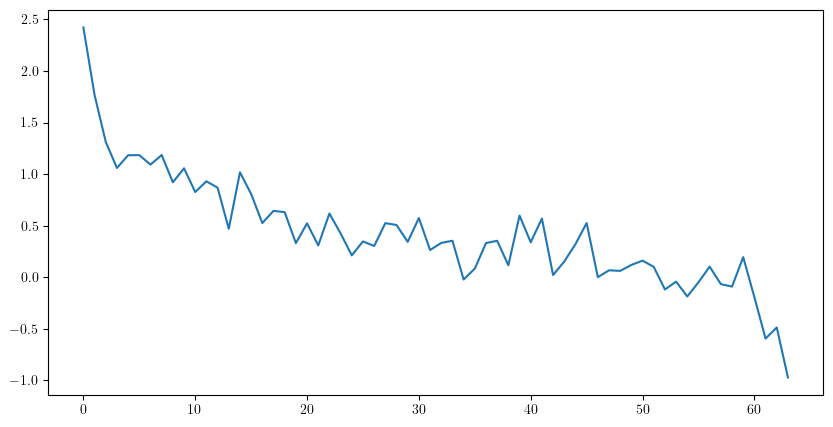

In [11]:
for sr_size in [0.2]:
    for nbins in [2**i for i in range(6, 7)]:
        for signal_ratio in [0.0]:
            for order in [0, 1, 2]:
                plot_pull_mean_over_bins(signal_ratio, sr_size, nbins, order=order)

Shape of the pull vs. signal region stats is important

## Null Case

Using base FvT score gives worse fit (given that there is no correction)

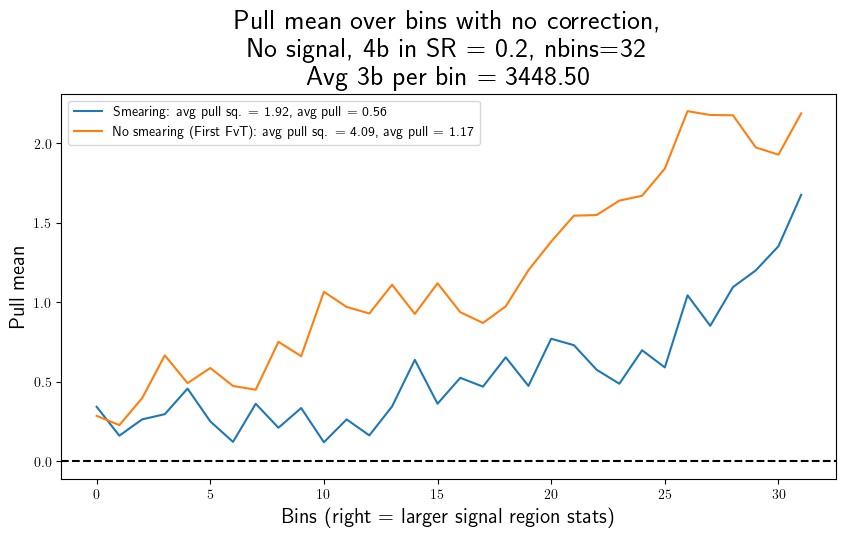

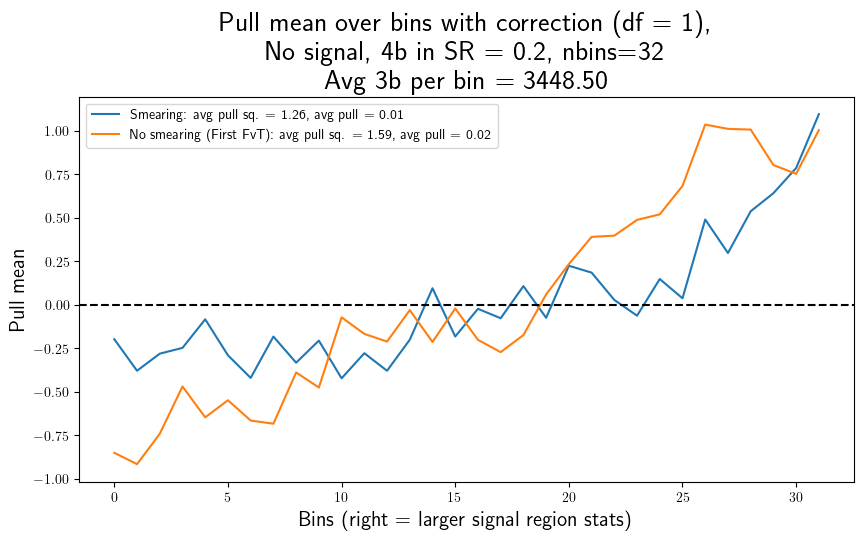

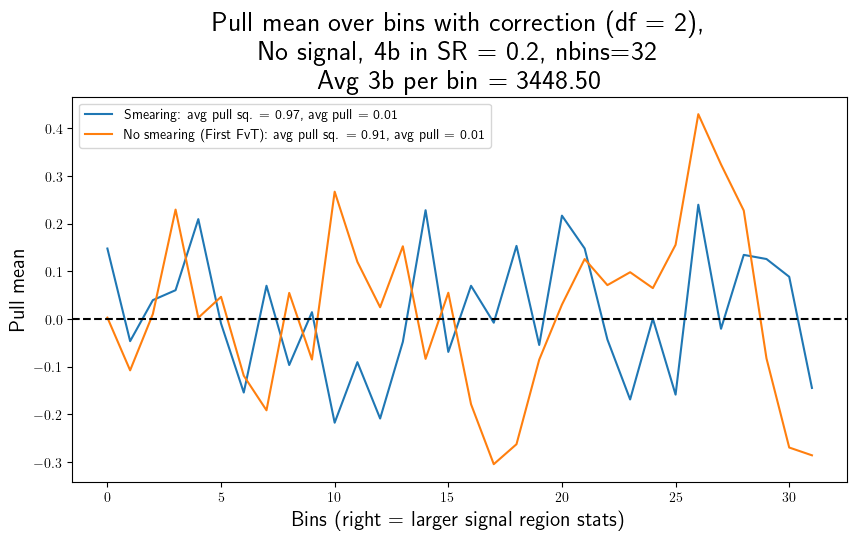

In [11]:
for sr_size in [0.2]:
    for nbins in [2**i for i in range(5, 6)]:
        for signal_ratio in [0]:
            for order in [0, 1, 2]:
                plot_pull_mean_over_bins(signal_ratio, sr_size, nbins, order=order)

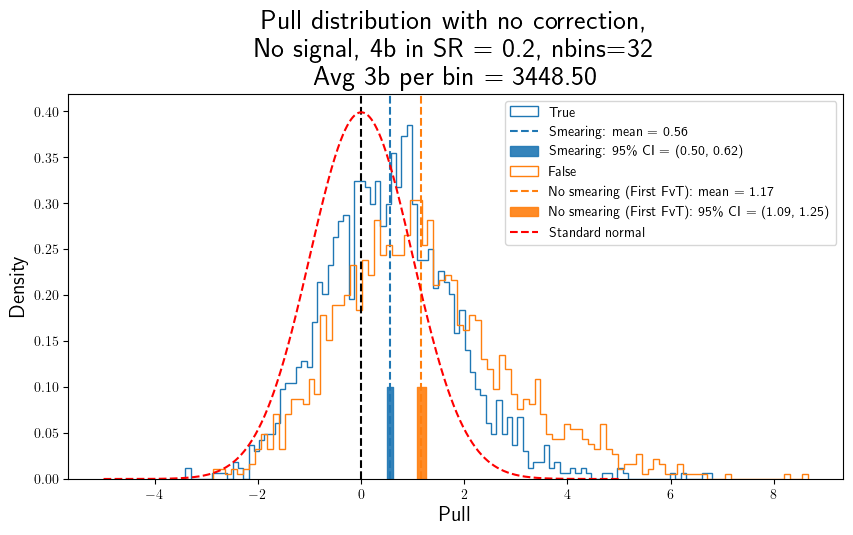

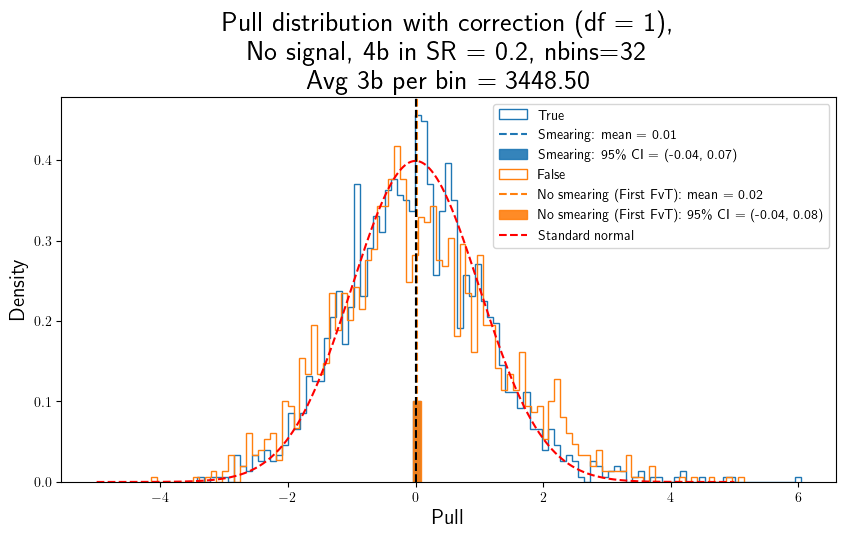

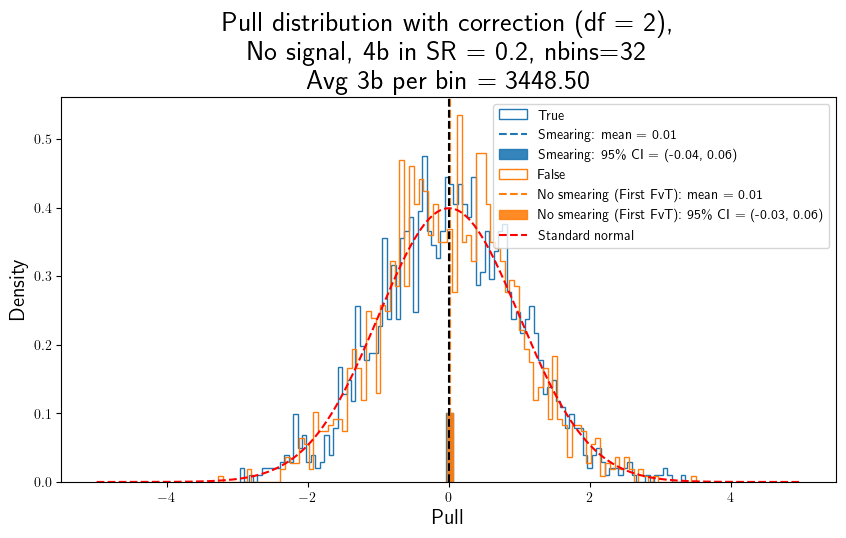

In [9]:
nbins = 2**5
signal_ratio = 0.0

for sr_size in [0.2]:
    for order in [0, 1, 2]:
        plot_pull_distribution(signal_ratio, sr_size, nbins, order=order)